## A nice little notebook for silly little toads to sonify parts of the Van Allen mission

Start by installing STRAUSS and cloning Rose's github, as well as grabbing CDFLib to open those NASA CDF files

In [ ]:
%pip --quiet install strauss
%pip install cdflib

!git clone https://github.com/rosedshepherd/soniTEA-STRAUSS.git

In [298]:
#strauss imports
from strauss.sonification import Sonification
from strauss.sources import Objects, Events
from strauss import channels
from strauss.score import Score
from strauss import sources as Sources
import numpy as np
from strauss.generator import Sampler, Synthesizer, Spectralizer
from strauss.tts_caption import render_caption

# other useful modules
import matplotlib.pyplot as plt
#from IPython.core.display import display, Markdown, Latex, Image

import cdflib
import urllib
from scipy import signal
from scipy.interpolate import interp1d
import re
from datetime import datetime
from rbspdataloaders import find_cdf_file, download_van_allen_files, download_van_allen_daterange
from rbspwaveprocessing import compute_filtered_waveform, compute_avg_wna_from_emfisis

## 2. Downloading the data
We use BeautifulSoup to search files on the NASA repositories, and grab the magnetic field, number density and wave data, assigning those variables to arrays

In [ ]:
NoDays = 2
startdate = datetime(2015,6, 27)
enddate = datetime(2015,6,27+NoDays)

data = download_van_allen_daterange('rbspa',startdate,enddate)

In [299]:
#Assign number density data
ne = data['density']
nEpoch = data['density_epoch']
t_num = (nEpoch-nEpoch[0])/(nEpoch[-1]-nEpoch[0])*(24*(NoDays+1)*3600)

#Assign magnetic field data
bmag= data['mag']
bEpoch = data['mag_epoch']
t_mag = (bEpoch-bEpoch[0])/(bEpoch[-1]-bEpoch[0])*(24*(NoDays+1)*3600)

# Assign wave data for each spacecraft direction
Bu_all = data['Bu']
Bv_all = data['Bv']
Bw_all = data['Bw']
WaveMags = np.sqrt(Bu_all.reshape(-1)**2+Bv_all.reshape(-1)**2+Bw_all.reshape(-1)**2)
wEpoch = data['wave_epoch']
t_wave = np.linspace(0,24*(NoDays+1),Bu_all.shape[0])

#Assign WNA files
frequencies = data['wfr_freqs']  # Hz
thsvd = data['thsvd'] # Wave normal angle (degrees)
bsum = data['bsum']  # Total magnetic power for weighting
plansvd = data['plansvd']  # Planarity (0-1)
WNAEpoch = data['wna_epoch']
t_wna = (WNAEpoch-WNAEpoch[0])/(WNAEpoch[-1]-WNAEpoch[0])*(24*(NoDays+1)*3600)

### 2.2 - Processing the wave data
This is done in 2 parts
1) Filter to the Whistler band 0.1fce<f<fce
2) Compute the wave normal angles associated with them

With both functions defined, compute Whistler band

fce range: 87317.0 - 93412.1 Hz
Looking for frequencies between 9341.1 and 93410.9 Hz
fce range: 87317.0 - 93412.1 Hz
Looking for frequencies between 9341.1 and 93410.9 Hz
fce range: 87317.0 - 93412.1 Hz
Looking for frequencies between 9341.1 and 93410.9 Hz


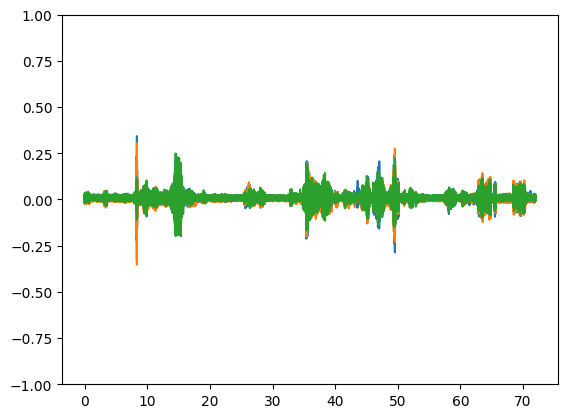

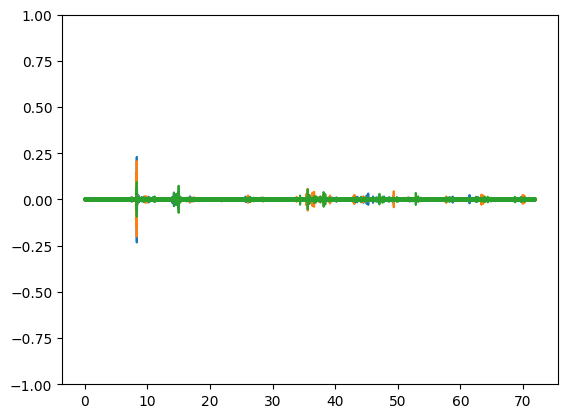

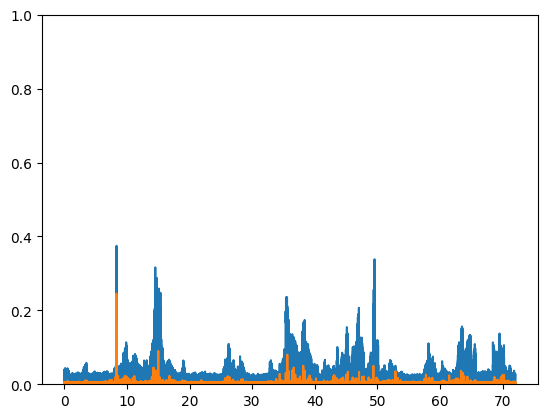

In [300]:
t_filter, Bu_filtered = compute_filtered_waveform(t_wave, Bu_all.reshape(-1), t_mag, bmag,256,None,0.1,1,'hann')
_, Bv_filtered = compute_filtered_waveform(t_wave, Bv_all.reshape(-1), t_mag, bmag,256,None,0.1,1,'hann')
_, Bw_filtered = compute_filtered_waveform(t_wave, Bw_all.reshape(-1), t_mag, bmag,256,None,0.1,1,'hann')

WaveMags_filtered = np.sqrt(Bu_filtered**2+Bv_filtered**2+Bw_filtered**2)

plt.plot(t_wave,Bu_all.reshape(-1))
plt.plot(t_wave,Bv_all.reshape(-1))
plt.plot(t_wave,Bw_all.reshape(-1))
plt.ylim(-1,1)
plt.show()
plt.plot(t_filter,Bu_filtered)
plt.plot(t_filter,Bv_filtered)
plt.plot(t_filter,Bw_filtered)
plt.ylim(-1,1)
plt.show()
plt.plot(t_wave,WaveMags)
plt.plot(t_filter,WaveMags_filtered)
plt.ylim(0,1)
plt.show()

In [301]:
t_wna, wna_avg = compute_avg_wna_from_emfisis(t_wna, t_mag, bmag,thsvd, plansvd, bsum, frequencies,0.1,1,0.5)

fce range: 3017.7 - 891073.2 Hz
Looking for frequencies between 9341.1 and 93410.9 Hz


Interpolate chorus data to cadence of magnetic field/number density

In [ ]:
WNA_interp_func = interp1d(t_wna, wna_avg, kind='linear',
                               bounds_error=False, fill_value='extrapolate')
Mags_interp_func = interp1d(t_mag, bmag, kind='linear',
                               bounds_error=False, fill_value='extrapolate')
WNA_chorus =  WNA_interp_func(t_filter*3600)
Mags_chorus = WaveMags_filtered/Mags_interp_func(t_filter*3600)
time_chorus = t_filter*3600

In [ ]:
print(f"t_mag points: {len(t_mag)}")
print(f"t_mag median cadence: {np.median(np.diff(t_mag))} seconds")
print(f"t_num mean cadence: {np.mean(np.diff(t_num))} seconds")
print(f"t_wna cadence: {np.median(np.diff(t_wna))} seconds")
print(f"t_wna cadence: {np.mean(np.diff(t_wna))} seconds")

Visualise data gathered thus far:

(0.0, 72.0)

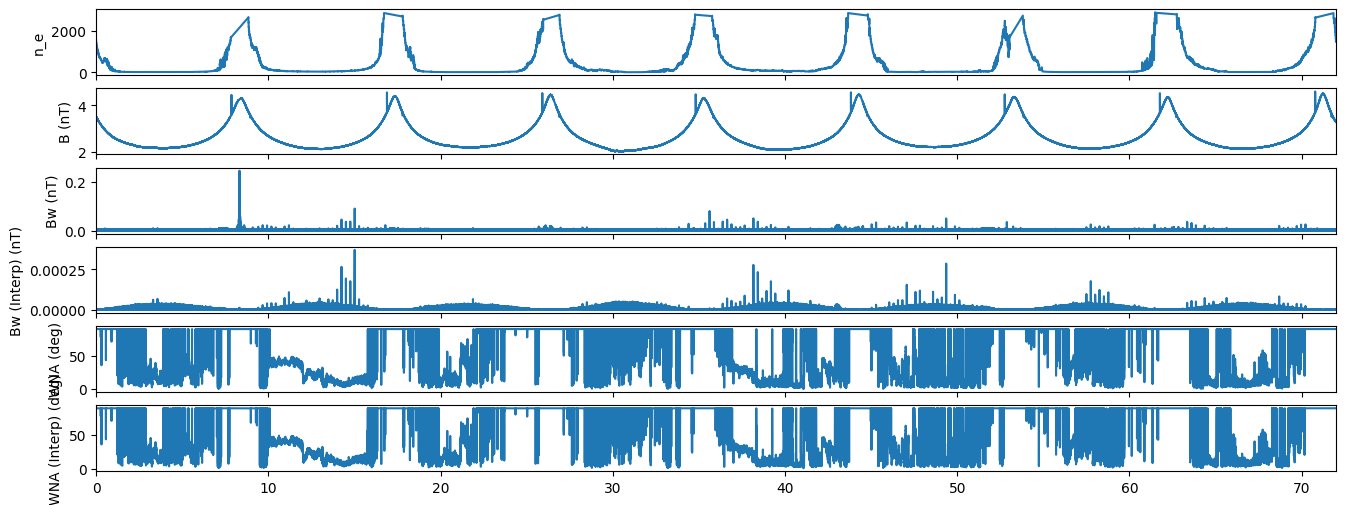

In [302]:
fig1, ax1 = plt.subplots(6,sharex = True,figsize=(16,6))



ax1[0].plot(t_num/t_num[-1]*24*(NoDays+1),ne)
ax1[0].set_ylabel('n_e')

ax1[1].plot(t_mag/t_mag[-1]*24*(NoDays+1),np.log10(bmag))
ax1[1].set_ylabel('B (nT)')

ax1[2].plot(t_filter/t_filter[-1]*24*(NoDays+1),WaveMags_filtered)
ax1[2].set_ylabel('Bw (nT)')


ax1[3].plot(t_filter/t_filter[-1]*24*(NoDays+1),(Mags_chorus))
ax1[3].set_ylabel('Bw (Interp) (nT)')

ax1[4].plot(t_wna/t_wna[-1]*24*(NoDays+1),wna_avg)
ax1[4].set_ylabel('WNA (deg)')

ax1[5].plot(t_filter/t_filter[-1]*24*(NoDays+1),WNA_chorus)
ax1[5].set_ylabel('WNA (Interp) (deg)')

ax1[-1].set_xlim(0,24*(NoDays+1))

## 3. The Sonifications
Actual code to sonify now! We do the number density first

In [ ]:
# Specify the notes used in the sonification,
# this time we will use a 'power chord' for harmonic richness, feel free to change these notes
notes = [["E1", "B2", "E2", "B3"]]

# Choose the duration of the sonification (here given in seconds)
length = 90

# Set up the Score! This just requires the permissible notes and the duration
# of the sound file you want to make (in secs)

score = Score(notes, length)

# selecting our parameters to map, we need to use lists which are the same length
# as the number of notes - this is why we have four elements in the pitch array
# and *4 for time_evo and cutoff
maps = {'pitch': [0,1,2,3],
          'time_evo': [t_num]*4, # we are now using time_evo instead of time,
          'cutoff': [ne]*4} # now mapping flux to cutoff parameter


# specify the mapping limits including the cutoff parameter, we want to use the full range of the data
lims = {'time_evo': ('0%','100%'),
          'cutoff': ('0%','100%')}

# Adding a parameter limits dictionary to control the range of the filter cutoff parameter
# input numbers 0 - 1 representing the fraction of audible frequencies that can be heard
# at the minimum and maximum range of the filter. Play around with these ✏️
plims = {'cutoff': (0.05,0.95)}

# Set up sources! This time we specify the Objects child class
sources = Objects(maps.keys())
sources.fromdict(maps)

# Now we apply mapping functions, including our parameter limits this time:
sources.apply_mapping_functions(map_lims = lims, param_lims = plims)

# Choosing the Synthesizer generator:
generator = Synthesizer()

# turning on the filter:
generator.modify_preset({'filter':'on'})

# uncomment the line below to try a 'textural' sonification using white noise! ✏️
#generator.load_preset('windy')

# Define our audio system, 'mono', 'stereo', '5.1'...
system = 'mono'

# call score, sources, generator and audio system (channels) to combine the modules
soni = Sonification(score, sources, generator, system)

# render sonification, we don't need to downsample for objects because the sound is continuous
soni.render()


#display in notebook with waveform
#dobj = soni.notebook_display();

soni.save('NumDensity.wav')

The next up is the sonification of the waves themselves, using a an event based mapping to pitch

In [ ]:
# Specify the notes used in the sonification,
# Most of a pentatonic scale here
notes = [["G2","B2","C3","D3","E3","G3","B3","C4","D4","E4","G4"]]

# Choose the duration of the sonification (here given in seconds)
length = 90

# Set up the Score! This just requires the permissible notes and the duration
# of the sound file you want to make (in secs)

score = Score(notes, length)

# Getting time and number density columns from our data


# selecting our parameters to map, we need to use lists which are the same length
# as the number of notes - this is why we have four elements in the pitch array
# and *4 for time_evo and cutoff
maps = {'volume': Mags_chorus,
        'pitch': np.exp(-WNA_chorus**2/(2*10**2)),
          'time': time_chorus}


# Here we set up our data limits, we want the time to go over 100% so the last note has time to play
lims = {'time': ('0%','100%'),
          'pitch': ('0%','100%'),
          'volume': ('0%','100%')}

# Set up sources! This time we specify the Objects child class
sources = Events(maps.keys())
sources.fromdict(maps)

# Now we apply mapping functions, including our parameter limits this time:
sources.apply_mapping_functions(map_lims = lims)

# Choosing the Sampler generator this time, pointing to the directory of audio samples:
generator = Sampler(sampfiles ='./soniTEA-STRAUSS/data/Samples/mallets')

# this time we will make use of the staccato preset rather than manually editing ADSR
generator.load_preset('staccato')

# Define our audio system, 'mono', 'stereo', '5.1'...
system = 'mono'

# call score, sources, generator and audio system (channels) to combine the modules
soni = Sonification(score, sources, generator, system)


# Set downsample factor, experiment by changing this, we might lose a lot of information
N = 200

# render sonification
soni.render(downsamp = N)


#display in notebook with waveform
#dobj = soni.notebook_display();

soni.save('Waves.wav')

In [ ]:
from IPython.display import Audio, display
%pip install pydub
from pydub import AudioSegment

# Load your two files
track1 = AudioSegment.from_wav("NumDensity.wav")
track2 = AudioSegment.from_wav("Waves.wav")

# Overlay them (mix together, starting at the same time)
combined = track1.overlay(track2)


# Export
combined.export("VanAllenExperience.wav", format="wav")


# If you've saved to file
display(Audio("VanAllenExperience.wav"))